In [6]:
import pandas as pd
df_output_dir = 'bayesian_analysis_output/res_01_21_11:03'

df = pd.read_csv(f'{df_output_dir}/target_table.csv')

# only shaw tolerance = 0.1%
df[df['Tolerance'] == "0.10%"]




,Configuration,Tolerance,TargetCost,BayesianFinalCost,MultiFinalCost,BayesianEvalsToTarget,MultiEvalsToTarget,EvalSpeedup_MultiOverBay,BayesTime@tau=0.01s,MultiTime@tau=0.01s,...,TimeSpeedup@tau=10.0s,BayesTime@tau=100.0s,MultiTime@tau=100.0s,TimeSpeedup@tau=100.0s,BayesTime@tau=1000.0s,MultiTime@tau=1000.0s,TimeSpeedup@tau=1000.0s,BayesTime@tau=10000.0s,MultiTime@tau=10000.0s,TimeSpeedup@tau=10000.0s
2,"2 coils, λ=1e-05",0.10%,0.032600,0.032560,0.032560,208.0,286.0,1.38,2.08,2.86,...,1.38,20800.0,28600.0,1.38,208000.0,286000.0,1.38,2080000.0,2860000.0,1.38
5,"2 coils, λ=1e-06",0.10%,0.005961,0.005956,0.005956,254.0,131.0,0.52,2.54,1.31,...,0.52,25400.0,13100.0,0.52,254000.0,131000.0,0.52,2540000.0,1310000.0,0.52
8,"2 coils, λ=1e-07",0.10%,0.002928,0.002925,0.002925,254.0,246.0,0.97,2.54,2.46,...,0.97,25400.0,24600.0,0.97,254000.0,246000.0,0.97,2540000.0,2460000.0,0.97
11,"2 coils, λ=1e-08",0.10%,0.002865,0.002862,0.002862,285.0,561.0,1.97,2.85,5.61,...,1.97,28500.0,56100.0,1.97,285000.0,561000.0,1.97,2850000.0,5610000.0,1.97
14,"3 coils, λ=1e-06",0.10%,0.002788,0.002785,0.002785,539.0,533.0,0.99,5.39,5.33,...,0.99,53900.0,53300.0,0.99,539000.0,533000.0,0.99,5390000.0,5330000.0,0.99
17,"3 coils, λ=1e-07",0.10%,0.000091,0.000091,0.000091,518.0,680.0,1.31,5.18,6.80,...,1.31,51800.0,68000.0,1.31,518000.0,680000.0,1.31,5180000.0,6800000.0,1.31
20,"3 coils, λ=1e-08",0.10%,0.000044,0.000044,0.000044,853.0,722.0,0.85,8.53,7.22,...,0.85,85300.0,72200.0,0.85,853000.0,722000.0,0.85,8530000.0,7220000.0,0.85
23,"4 coils, λ=1e-06",0.10%,0.001558,0.001556,0.001556,889.0,811.0,0.91,8.89,8.11,...,0.91,88900.0,81100.0,0.91,889000.0,811000.0,0.91,8890000.0,8110000.0,0.91
26,"4 coils, λ=1e-07",0.10%,0.000053,0.000053,0.000053,21918.0,1432.0,0.07,219.18,14.32,...,0.07,2192000.0,143200.0,0.07,21920000.0,1432000.0,0.07,219200000.0,14320000.0,0.07
29,"4 coils, λ=1e-08",0.10%,0.000008,0.000008,0.000008,18553.0,11503.0,0.62,185.53,115.03,...,0.62,1855000.0,1150000.0,0.62,18550000.0,11500000.0,0.62,185500000.0,115000000.0,0.62


In [7]:
from IPython.display import display
import pandas as pd
import re

# Load table if df not already defined
try:  # noqa: F821
    df  # type: ignore[name-defined]
except NameError:
    df = pd.read_csv(f'{df_output_dir}/target_table.csv')

# Extract coil count from the 'Configuration' string if needed
if 'coils' not in df.columns:
    if 'Configuration' in df.columns:
        df['coils'] = df['Configuration'].str.extract(r'^(\d+)\s+coils').astype(int)
    else:
        raise KeyError("Expected 'Configuration' column to derive 'coils'.")

# Create a numeric tolerance column in [0,1]
if 'tolerance' in df.columns:
    df['_tol_num'] = df['tolerance']
elif 'Tolerance' in df.columns:
    df['_tol_num'] = df['Tolerance'].astype(str).str.rstrip('%').astype(float) / 100.0
else:
    df['_tol_num'] = pd.NA

# Choose a TimeSpeedup column (prefer tau=1.0s)
time_col = 'TimeSpeedup@tau=1.0s'
if time_col not in df.columns:
    time_cols = [c for c in df.columns if c.startswith('TimeSpeedup@tau=')]
    if not time_cols:
        raise KeyError('No TimeSpeedup@tau=... columns found in dataframe')
    time_col = 'TimeSpeedup@tau=1.0s' if 'TimeSpeedup@tau=1.0s' in time_cols else time_cols[0]

# Per-coil average across all tolerances
avg_per_coil_all = (
    df.groupby('coils', as_index=False)[time_col]
      .mean()
      .rename(columns={time_col: f'avg_{time_col}'})
)

# Helper to hide the left index in rich display

def _hide_index(df_: pd.DataFrame):
    styler = df_.style
    if hasattr(styler, 'hide_index'):
        return styler.hide_index()
    try:
        return styler.hide(axis='index')
    except Exception:
        return df_

# Per-coil average at tolerance = 0.001 (i.e., 0.10%)
mask_tol_0p1 = df['_tol_num'].notna() & (df['_tol_num'] == 0.001)
if mask_tol_0p1.any():
    avg_per_coil_tol_0p1 = (
        df.loc[mask_tol_0p1].groupby('coils', as_index=False)[time_col]
          .mean()
          .rename(columns={time_col: f'avg_{time_col}_tol0p1pct'})
    )
else:
    avg_per_coil_tol_0p1 = pd.DataFrame(columns=['coils', f'avg_{time_col}_tol0p1pct'])

# Per-coil average at tolerance = 1%
mask_tol_1 = df['_tol_num'].notna() & (df['_tol_num'] == 0.01)
if mask_tol_1.any():
    avg_per_coil_tol_1 = (
        df.loc[mask_tol_1].groupby('coils', as_index=False)[time_col]
          .mean()
          .rename(columns={time_col: f'avg_{time_col}_tol1pct'})
    )
else:
    avg_per_coil_tol_1 = pd.DataFrame(columns=['coils', f'avg_{time_col}_tol1pct'])

# Per-coil average at tolerance = 10%
mask_tol_10 = df['_tol_num'].notna() & (df['_tol_num'] == 0.10)
if mask_tol_10.any():
    avg_per_coil_tol_10 = (
        df.loc[mask_tol_10].groupby('coils', as_index=False)[time_col]
          .mean()
          .rename(columns={time_col: f'avg_{time_col}_tol10pct'})
    )
else:
    avg_per_coil_tol_10 = pd.DataFrame(columns=['coils', f'avg_{time_col}_tol10pct'])

# Display with hidden index
display(_hide_index(avg_per_coil_all))
display(_hide_index(avg_per_coil_tol_0p1))
display(_hide_index(avg_per_coil_tol_1))
display(_hide_index(avg_per_coil_tol_10))


coils,avg_TimeSpeedup@tau=1.0s
2,1.395000
3,1.147778
4,0.693333
5,8.313333
6,13.566000


coils,avg_TimeSpeedup@tau=1.0s_tol0p1pct
2,1.210000
3,1.050000
4,0.533333
5,10.910000
6,25.340000


coils,avg_TimeSpeedup@tau=1.0s_tol1pct
2,1.210000
3,1.046667
4,0.830000
5,7.135000
6,34.090000


coils,avg_TimeSpeedup@tau=1.0s_tol10pct
2,1.765000
3,1.346667
4,0.716667
5,8.233333
6,2.800000


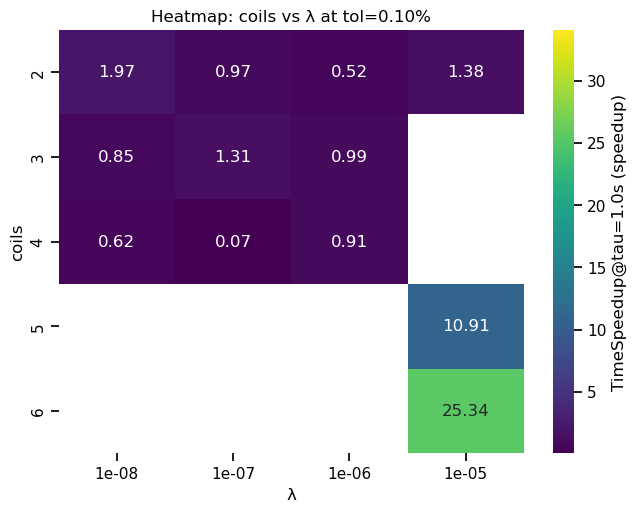

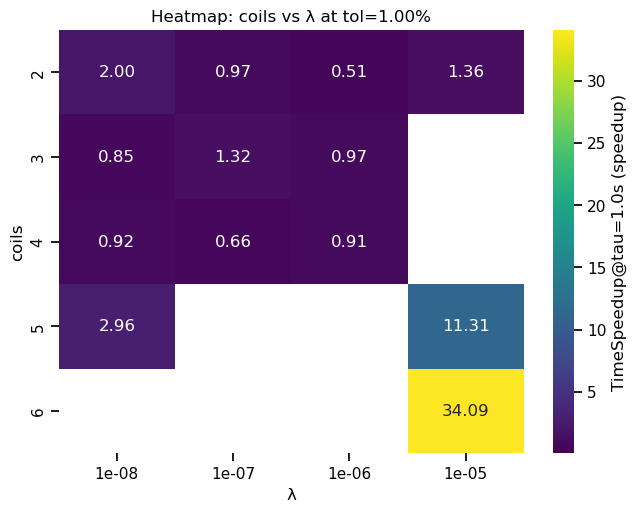

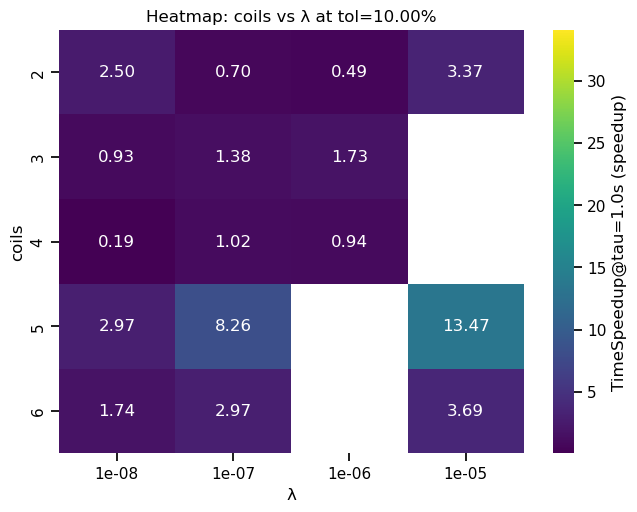

In [9]:
# Single heatmap per tolerance (rows=coils, cols=λ) with annotations
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure lambda parsed
if 'lambda' not in df.columns:
    if 'Configuration' in df.columns:
        df['lambda'] = df['Configuration'].str.extract(r'λ=([0-9.eE+\-]+)')[0].astype(float)
    else:
        raise KeyError("Expected 'Configuration' to derive 'lambda'.")

# Determine tolerances to plot (prefer standard order)
preferred_tols = [0.001, 0.01, 0.10]
if '_tol_num' not in df.columns:
    raise KeyError("'_tol_num' not found; run the first cell to prepare dataframe.")

available_tols = [t for t in preferred_tols if (df['_tol_num'] == t).any()]
if not available_tols:
    available_tols = sorted(df['_tol_num'].dropna().unique().tolist())

# Consistent color scale across tolerances
vals = df[df['_tol_num'].isin(available_tols)][time_col].astype(float)
vmin, vmax = float(vals.min()), float(vals.max())

sns.set_context('notebook')
for tol in available_tols:
    df_filt = df[df['_tol_num'] == tol]
    pivot_coils_lambda = (
        df_filt.pivot_table(index='coils', columns='lambda', values=time_col, aggfunc='mean')
              .sort_index()
    )
    if pivot_coils_lambda.columns.is_monotonic_increasing is False:
        pivot_coils_lambda = pivot_coils_lambda.reindex(sorted(pivot_coils_lambda.columns), axis=1)

    plt.figure(figsize=(7.5, 5.5))
    sns.heatmap(
        pivot_coils_lambda, annot=True, fmt='.2f', cmap='viridis',
        vmin=vmin, vmax=vmax, cbar_kws={'label': f'{time_col} (speedup)'}
    )
    plt.title(f'Heatmap: coils vs λ at tol={tol*100:.2f}%')
    plt.xlabel('λ')
    plt.ylabel('coils')
    plt.show()


In [11]:
# Significance per tolerance
import pandas as pd
import numpy as np
import math
from IPython.display import display

# Ensure tidy 'melted' frame exists; if not, rebuild
try:
    melted  # noqa: F821
except NameError:
    try:
        df
    except NameError:
        df = pd.read_csv(f'{df_output_dir}/target_table.csv')
    if 'coils' not in df.columns:
        df['coils'] = df['Configuration'].str.extract(r'^(\d+)\s+coils').astype(int)
    if 'lambda' not in df.columns:
        df['lambda'] = df['Configuration'].str.extract(r'λ=([0-9.eE+\-]+)')[0].astype(float)
    if '_tol_num' not in df.columns:
        df['_tol_num'] = df['Tolerance'].astype(str).str.rstrip('%').astype(float) / 100.0
    speed_cols = [c for c in df.columns if c.startswith('TimeSpeedup@tau=')]
    melted = df.melt(
        id_vars=['coils', 'lambda', '_tol_num'],
        value_vars=speed_cols,
        var_name='tau_col', value_name='speedup'
    )
    melted['tau'] = (
        melted['tau_col'].str.extract(r'TimeSpeedup@tau=([0-9.eE+\-]+)s')[0].astype(float)
    )
    melted = melted[np.isfinite(melted['speedup']) & (melted['speedup'] > 0)]

# Helpers if not already defined in session
try:
    geometric_mean_ci_bootstrap  # noqa: F821
except NameError:
    rng = np.random.default_rng(12345)
    def geometric_mean_ci_bootstrap(values: np.ndarray, reps: int = 10000, alpha: float = 0.05):
        logs = np.log(values)
        n = len(values)
        if n == 0:
            return np.nan, np.nan, np.nan
        gmean = float(np.exp(logs.mean()))
        idx = rng.integers(0, n, size=(reps, n))
        boot_means = logs[idx].mean(axis=1)
        low, high = np.percentile(boot_means, [100*alpha/2, 100*(1-alpha/2)])
        return gmean, float(np.exp(low)), float(np.exp(high))

try:
    wilson_ci  # noqa: F821
except NameError:
    def wilson_ci(k: int, n: int, alpha: float = 0.05):
        if n == 0:
            return (np.nan, np.nan)
        z = 1.959963984540054
        phat = k / n
        denom = 1 + (z**2)/n
        center = (phat + (z**2)/(2*n)) / denom
        half = (z/denom) * math.sqrt(phat*(1-phat)/n + (z**2)/(4*n**2))
        return max(0.0, center - half), min(1.0, center + half)

try:
    sign_test_pvalue  # noqa: F821
except NameError:
    def sign_test_pvalue(pos: int, neg: int):
        n = pos + neg
        if n == 0:
            return np.nan
        p = 0.0
        for k in range(pos, n+1):
            p += math.comb(n, k)
        return p / (2**n)

try:
    from scipy.stats import wilcoxon  # type: ignore
except Exception:
    wilcoxon = None  # type: ignore

# Filter to tau=0.01s
tau_target = 0.01
m_tau = melted[np.isclose(melted['tau'], tau_target)]

rows = []
for tol, g in m_tau.groupby('_tol_num'):
    vals = g['speedup'].to_numpy(dtype=float)
    log_vals = np.log(vals)
    pos = int(np.sum(log_vals > 0))
    neg = int(np.sum(log_vals < 0))
    n_pairs = int(pos + neg)

    gm, gm_lo, gm_hi = geometric_mean_ci_bootstrap(vals)
    wins = int(np.sum(vals > 1.0))
    win_rate = wins / int(vals.size) if vals.size > 0 else np.nan
    wr_lo, wr_hi = wilson_ci(wins, int(vals.size))

    sign_p = sign_test_pvalue(pos, neg) if n_pairs > 0 else np.nan

    w_p = np.nan
    if wilcoxon is not None and n_pairs > 0:
        try:
            res = wilcoxon(log_vals[log_vals != 0.0], zero_method='wilcox', alternative='greater', correction=False)
            w_p = float(res.pvalue)
        except TypeError:
            res = wilcoxon(log_vals[log_vals != 0.0], zero_method='wilcox')
            w_two = float(res.pvalue)
            w_p = w_two/2 if pos > neg else 1 - (1 - w_two/2)
        except Exception:
            w_p = np.nan

    rows.append({
        'tol': float(tol),
        'n_pairs': n_pairs,
        'geom_mean_speedup': gm,
        'geom_ci_low': gm_lo,
        'geom_ci_high': gm_hi,
        'win_rate': win_rate,
        'win_ci_low': wr_lo,
        'win_ci_high': wr_hi,
        'median_speedup': float(np.exp(np.median(log_vals))) if vals.size > 0 else np.nan,
        'wilcoxon_p': w_p,
        'sign_p': sign_p,
    })

summary_tau001 = pd.DataFrame(rows).sort_values('tol').reset_index(drop=True)

# Save and display (no tau column)
out_path = f'{df_output_dir}/summary_stats_tau0p01_raw.csv'
try:
    summary_tau001.to_csv(out_path, index=False)
except Exception:
    pass

try:
    styler = summary_tau001.style.hide_index().format({
        'tol': '{:.3%}',
        'geom_mean_speedup': '{:.3f}',
        'geom_ci_low': '{:.3f}',
        'geom_ci_high': '{:.3f}',
        'win_rate': '{:.1%}',
        'win_ci_low': '{:.1%}',
        'win_ci_high': '{:.1%}',
        'median_speedup': '{:.3f}',
        'wilcoxon_p': '{:.3g}',
        'sign_p': '{:.3g}',
    })
    display(styler)
except Exception:
    display(summary_tau001)


,tol,n_pairs,geom_mean_speedup,geom_ci_low,geom_ci_high,win_rate,win_ci_low,win_ci_high,median_speedup,wilcoxon_p,sign_p
0,0.001,12,1.263186,0.576060,2.899921,0.416667,0.193260,0.680489,0.979949,0.425049,0.806152
1,0.010,13,1.690869,0.975957,3.329672,0.461538,0.232061,0.708562,0.970000,0.187866,0.709473
2,0.100,16,1.744614,1.052733,2.886532,0.687500,0.444044,0.858354,1.734993,0.032700,0.105057


In [ ]:
# Tests: log ⁡ ( speedup ) ∼ log ⁡ ( 𝜆 ) + coils 
# This answers: “Does Bayesian get more advantageous as λ or coils increase?”



In [12]:
# Linear regression per tolerance: log(speedup) ~ log(lambda) + coils (coils numeric), τ ignored
# - Uses TimeSpeedup@tau=0.01s to avoid duplicate rows (τ-invariant)
# - Reports R^2, coefficient estimates, 95% CIs (and p-values if SciPy available)
# - Reports missing combos per tolerance (non-finite or <=0 speedup)

import pandas as pd
import numpy as np
from IPython.display import display

# Prepare base dataframe from target_table
try:
    df
except NameError:
    df = pd.read_csv(f'{df_output_dir}/target_table.csv')

# Ensure needed columns
if 'coils' not in df.columns:
    df['coils'] = df['Configuration'].str.extract(r'^(\d+)\s+coils').astype(int)
if 'lambda' not in df.columns:
    df['lambda'] = df['Configuration'].str.extract(r'λ=([0-9.eE+\-]+)')[0].astype(float)
if '_tol_num' not in df.columns:
    if 'Tolerance' in df.columns:
        df['_tol_num'] = df['Tolerance'].astype(str).str.rstrip('%').astype(float) / 100.0
    else:
        raise KeyError("Expected 'Tolerance' to derive numeric tolerance.")

# Choose a single tau column for speedup (τ-invariant)
if 'TimeSpeedup@tau=0.01s' in df.columns:
    sp_col = 'TimeSpeedup@tau=0.01s'
else:
    # fallback: first available
    sp_candidates = [c for c in df.columns if c.startswith('TimeSpeedup@tau=')]
    if not sp_candidates:
        raise KeyError('No TimeSpeedup@tau=... columns found')
    sp_col = sp_candidates[0]

base = df[['coils','lambda','_tol_num', sp_col]].rename(columns={sp_col:'speedup'})

# Count missing combos per tolerance (non-finite or <=0 speedup)
base['is_valid'] = np.isfinite(base['speedup']) & (base['speedup'] > 0)

# OLS utilities (no external deps required for CIs; p-values if SciPy is available)
from scipy.stats import t as student_t  # type: ignore

def fit_ols_with_ci(X: np.ndarray, y: np.ndarray, alpha: float = 0.05):
    n, p = X.shape
    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)
    beta = XtX_inv @ (X.T @ y)
    resid = y - X @ beta
    dof = max(n - p, 1)
    sigma2 = float(resid.T @ resid) / dof
    cov = sigma2 * XtX_inv
    se = np.sqrt(np.diag(cov))
    # critical value
    if student_t is not None:
        tcrit = float(student_t.ppf(1 - alpha/2, dof))
    else:
        tcrit = 1.96
    ci_low = beta - tcrit * se
    ci_high = beta + tcrit * se
    # p-values if SciPy is available
    if student_t is not None:
        tstats = beta / se
        pvals = 2 * (1 - student_t.cdf(np.abs(tstats), dof))
    else:
        pvals = np.full_like(beta, np.nan, dtype=float)
    # R^2
    y_mean = y.mean() if n > 0 else 0.0
    ss_tot = float(((y - y_mean)**2).sum())
    ss_res = float((resid**2).sum())
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return beta, se, ci_low, ci_high, pvals, r2, dof

rows = []
for tol, g in base.groupby('_tol_num'):
    total = int(len(g))
    used = g[g['is_valid']].copy()
    n_missing = total - int(len(used))
    if used.empty:
        continue
    # Design matrix: intercept, log(lambda), coils (numeric)
    y = np.log(used['speedup'].to_numpy(dtype=float))
    X = np.column_stack([
        np.ones(len(used), dtype=float),
        np.log(used['lambda'].to_numpy(dtype=float)),
        used['coils'].to_numpy(dtype=float),
    ])
    beta, se, ci_lo, ci_hi, pvals, r2, dof = fit_ols_with_ci(X, y)
    terms = ['Intercept', 'log_lambda', 'coils']
    for i, term in enumerate(terms):
        rows.append({
            'tol': float(tol),
            'term': term,
            'estimate': float(beta[i]),
            'ci_low': float(ci_lo[i]),
            'ci_high': float(ci_hi[i]),
            'p_value': float(pvals[i]) if np.isfinite(pvals[i]) else np.nan,
            'R2': float(r2),
            'n_used': int(len(used)),
            'n_missing': int(n_missing),
            'dof': int(dof),
        })

reg_table = pd.DataFrame(rows).sort_values(['tol','term']).reset_index(drop=True)

# Save & display
out_path = f'{df_output_dir}/regression_by_tol.csv'
reg_table.to_csv(out_path, index=False)

try:
    styler = reg_table.style.hide_index().format({
        'tol': '{:.3%}',
        'estimate': '{:.4f}',
        'ci_low': '{:.4f}',
        'ci_high': '{:.4f}',
        'p_value': '{:.3g}',
        'R2': '{:.3f}',
        'n_used': '{:d}',
        'n_missing': '{:d}',
        'dof': '{:d}',
    })
    display(styler)
except Exception:
    display(reg_table[reg_table['term'] != 'Intercept'])


,tol,term,estimate,ci_low,ci_high,p_value,R2,n_used,n_missing,dof
1,0.001,coils,0.376128,-0.356190,1.108445,0.275172,0.358174,12,4,9
2,0.001,log_lambda,0.215235,-0.139555,0.570025,0.203185,0.358174,12,4,9
4,0.010,coils,0.583926,0.173556,0.994297,0.009980,0.598240,13,3,10
5,0.010,log_lambda,0.137625,-0.061094,0.336343,0.153831,0.598240,13,3,10
7,0.100,coils,0.298573,-0.046816,0.643963,0.084532,0.331522,16,0,13
8,0.100,log_lambda,0.162577,-0.037341,0.362496,0.102455,0.331522,16,0,13
